In [1]:
import numpy as np
import matplotlib.pyplot as plt

from optimal_loss import compute_optimal_loss

In [2]:
def get_plot_exact(ax, eps):
  deltas = np.logspace(-5, -2, 100)
  min_losses = [compute_optimal_loss(eps=eps, delta=delta, exact=True) for delta in deltas]

  ax.plot(deltas, min_losses, label=rf'Privacy Budget $\varepsilon={eps}$')
  ax.set_xscale('log')
  ax.set_xlabel(r'Failure Probability $\delta$')
  ax.set_ylabel('Expected Loss Upper Bound')
  ax.set_title(r"Exact Solve ($\tau=\eta=0$)")

In [3]:
def get_plot_inexact(ax, eps):
  deltas = np.logspace(-5, -2, 100)
  min_losses = [compute_optimal_loss(eps=eps, delta=delta, exact=False) for delta in deltas]
  min_losses = [x if x <= 3500 else None for x in min_losses]

  ax.plot(deltas, min_losses, ".", label=rf'Privacy Budget $\varepsilon={eps}$')
  ax.set_xscale('log')
  ax.set_xlabel(r'Failure Probability $\delta$')
  ax.set_ylabel('Expected Loss Upper Bound')
  ax.set_title(r"Inexact Solve ($\tau=\eta=0.001$)")

/Users/danielcortild/Documents/QOP-Mechanism/loss_constants.py:10: RuntimeWarning: overflow encountered in scalar multiply
  gamma(d / 2 + 1)
/Users/danielcortild/Documents/QOP-Mechanism/loss_constants.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  return 2 * inv_inc_gamma(del3 / Dm, (m - d + 1) / 2)
/Users/danielcortild/Documents/QOP-Mechanism/loss_constants.py:25: RuntimeWarning: divide by zero encountered in scalar divide
  return inv_inc_gamma(del1 * (1 - del3) / Dm + inc_gamma(alpha, shape), shape) - alpha


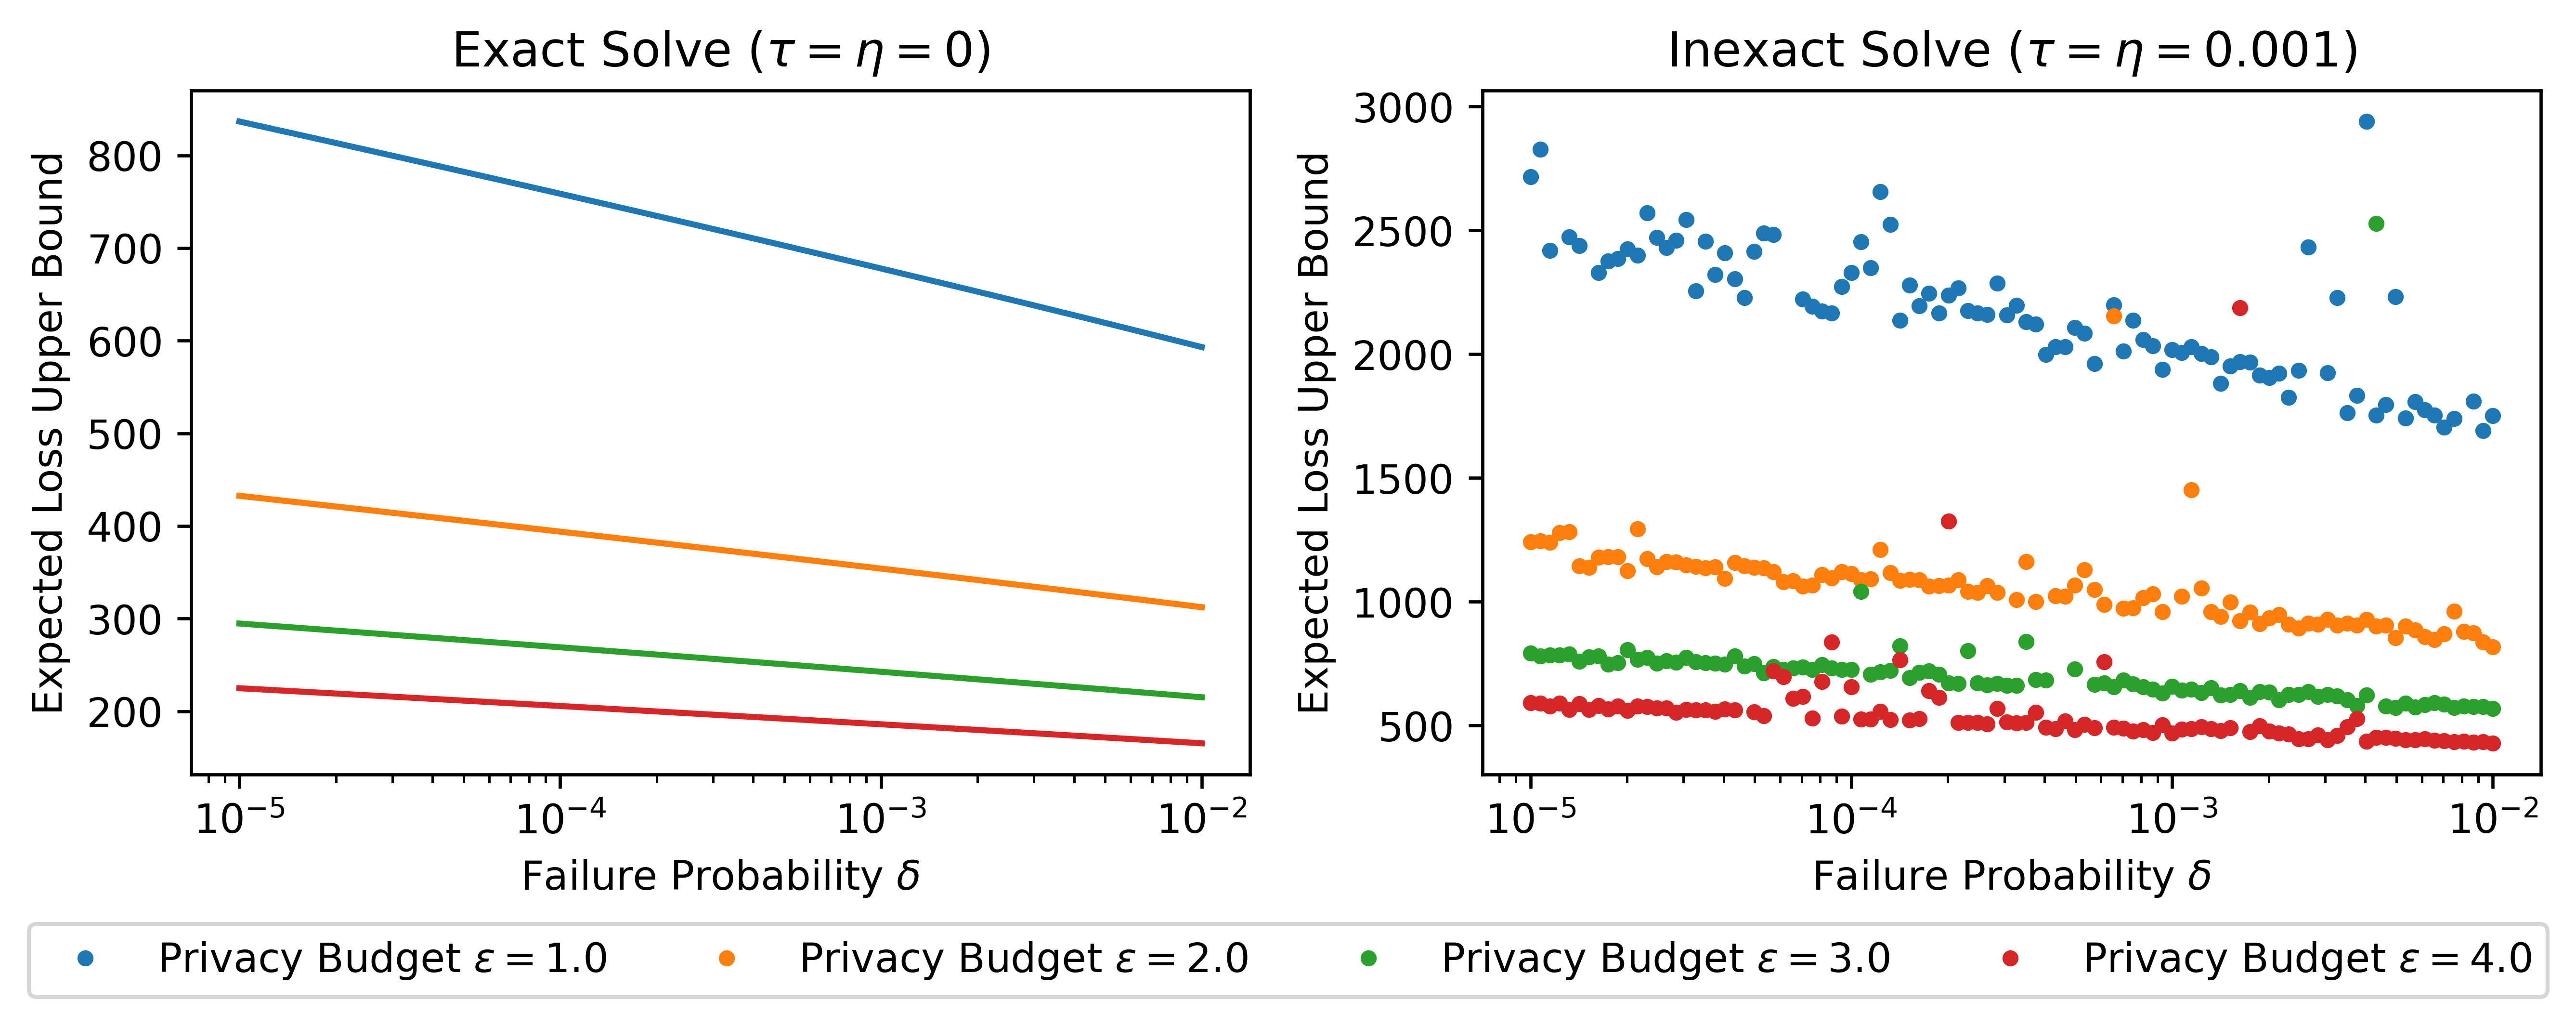

In [4]:
fig, axs = plt.subplots(nrows=1, ncols=2, dpi=600, figsize=(9, 3.5))

get_plot_exact(axs[0], 1.00)
get_plot_exact(axs[0], 2.00)
get_plot_exact(axs[0], 3.00)
get_plot_exact(axs[0], 4.00)

get_plot_inexact(axs[1], 1.00)
get_plot_inexact(axs[1], 2.00)
get_plot_inexact(axs[1], 3.00)
get_plot_inexact(axs[1], 4.00)

handles, labels = axs[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),  # centered below the figure
    ncols=len(labels)             # optional: put entries on one row
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
plt.savefig("F1_UtilityBound.png")
plt.show()